# Coherent pullback branches for the Böttcher coordinate

This notebook visualizes the geometric obstruction behind the remaining Lean target

```lean
Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

For $f(z)=z^2+2$, the near-infinity coordinate $\Phi_\infty$ is already constructed in Lean as `MLC.logSeriesBottcherApprox`. For a basin point $z$, a basin extension should be defined by choosing $N$ such that $f^N(z)$ is near infinity and setting

$$
\Phi(z) = \left(\Phi_\infty(f^N(z))\right)^{1/2^N}.
$$

The missing issue is not the formula; it is the **branch choice**. The equation $w^{2^N}=\Phi_\infty(f^N(z))$ has $2^N$ roots. The root chosen at time $N$ must agree with the root chosen at time $N+1$, and must vary holomorphically in $z$. A naive principal root generally does not supply that coherence.

## What “pullback” means here

Near infinity we already have a coordinate $
\Phi_\infty
$ satisfying the Böttcher equation

$$
\Phi_\infty(f(z))=\Phi_\infty(z)^2.
$$

If a basin point $z$ is not yet near infinity, choose an escape time $N$ such that $f^N(z)$ is in the near-infinity region. Then $\Phi_\infty(f^N(z))$ is known. To recover a possible value of $\Phi(z)$, solve

$$
w^{2^N}=\Phi_\infty(f^N(z)).
$$

This backwards recovery is the “pullback”: we pull the known near-infinity coordinate value back through $N$ iterates of the squaring map. Algebraically there are $2^N$ possible roots. A coherent basin coordinate must choose one root at each level so that the choice at level $N+1$ agrees with the choice at level $N$, and so that the choice varies holomorphically with $z$.

The naive principal-root pullback means: at every level, take the principal complex root. The problem is that principal roots use a fixed branch cut, so the principal choice at level $N+1$ need not be compatible with the principal choice at level $N$.

In [1]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

c = 2.0 + 0.0j

def f(z):
    return z*z + c

def iterate(z, n):
    for _ in range(n):
        z = f(z)
    return z

def escape_time(z, R=4.0, max_iter=30):
    w = z
    for n in range(max_iter + 1):
        if abs(w) > R:
            return n
        w = f(w)
    return None

def principal_root(w, degree):
    return cmath.exp(cmath.log(w) / degree)

def all_roots(w, degree):
    r = abs(w) ** (1 / degree)
    theta = cmath.phase(w)
    return np.array([r * cmath.exp(1j * (theta + 2 * math.pi * k) / degree) for k in range(degree)])

## A finite near-infinity approximation

The Lean coordinate is represented by a logarithmic correction series. For visualization, use the finite approximation

$$
\Phi_M(z)=z\exp\left(\sum_{n=0}^{M-1}2^{-(n+1)}\log\left(1+\frac{2}{f^n(z)^2}\right)\right).
$$

This is only for visualization; the Lean development proves the corresponding convergence/near-infinity package exactly.

In [2]:
def phi_inf_approx(z, terms=40):
    s = 0.0 + 0.0j
    w = z
    for n in range(terms):
        s += (0.5 ** (n + 1)) * cmath.log(1 + c / (w*w))
        w = f(w)
        if abs(w) > 1e80:
            break
    return z * cmath.exp(s)

def pullback_candidate(z, N, terms=40):
    W = phi_inf_approx(iterate(z, N), terms=terms)
    return principal_root(W, 2**N)

## Root choices at one basin point

At escape time $N$, the equation $w^{2^N}=\Phi_\infty(f^N(z))$ has $2^N$ possible roots. The principal root is just one arbitrary branch. The coherent branch is the one compatible with nearby points and with later escape times.

escape time for z0 = 2 f^N(z0)= (6+0j)


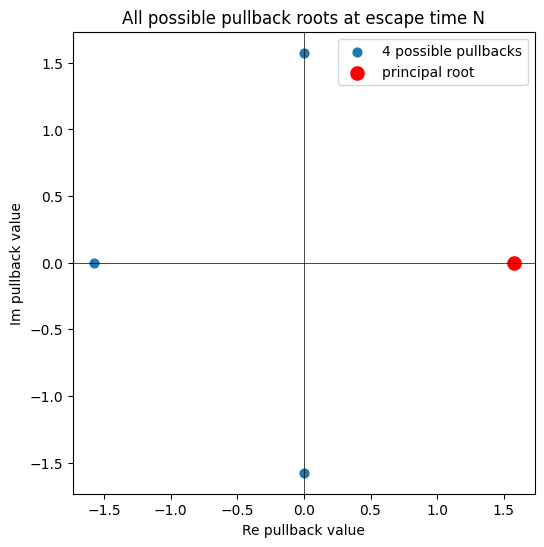

In [3]:
z0 = 0.0 + 0.0j
N = escape_time(z0, R=4.0, max_iter=10)
print('escape time for z0 =', N, 'f^N(z0)=', iterate(z0, N))

W = phi_inf_approx(iterate(z0, N), terms=50)
roots = all_roots(W, 2**N)
principal = principal_root(W, 2**N)

plt.figure(figsize=(6, 6))
plt.scatter(roots.real, roots.imag, s=40, label=f'{2**N} possible pullbacks')
plt.scatter([principal.real], [principal.imag], color='red', s=90, label='principal root')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.title('All possible pullback roots at escape time N')
plt.xlabel('Re pullback value')
plt.ylabel('Im pullback value')
plt.legend()
plt.show()

## A concrete branch decision

For a fixed point $z_0$, suppose $N$ is the first time such that $f^N(z_0)$ is near infinity.

At level $N$ we get a finite root cloud

$$
\{w:w^{2^N}=\Phi_\infty(f^N(z_0))\}.
$$

At level $N+1$ we get another cloud

$$
\{w:w^{2^{N+1}}=\Phi_\infty(f^{N+1}(z_0))\}.
$$

If the Böttcher equation near infinity were exact numerically, every coherent level-$N$ choice would also appear among the level-$(N+1)$ choices, because

$$
\Phi_\infty(f^{N+1}(z_0))=\Phi_\infty(f^N(z_0))^2.
$$

So the branch decision is not “pick any descendant.” It is: pick the same analytic branch value consistently as the escape time changes. The plot below shows the two root clouds and connects each level-$N$ root to its nearest level-$(N+1)$ match. A coherent choice should follow these near-identity matches; the principal root at each level may jump to a different point because it is selected by a global branch cut.

z0 = 0j
escape time N = 2
f^N(z0) = (6+0j)
chosen root at N          = 1.5758342+0j
principal root at N+1     = 1.5758342+0j
nearest coherent at N+1   = 1.5758342+0j
distance principal N+1    = 2.22e-16
distance coherent N+1     = 2.22e-16


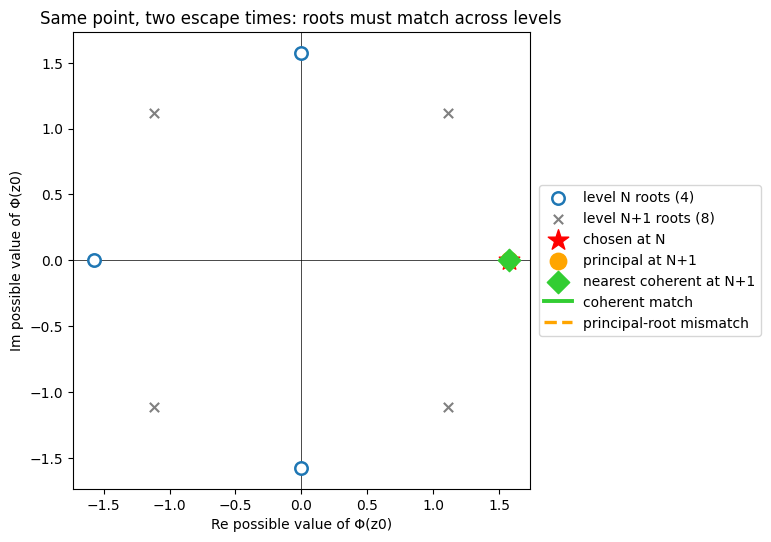

In [4]:
z0 = 0.0 + 0.0j
N = escape_time(z0, R=4.0, max_iter=10)
W_N = phi_inf_approx(iterate(z0, N), terms=60)
W_N1 = phi_inf_approx(iterate(z0, N + 1), terms=60)

roots_N = all_roots(W_N, 2**N)
roots_N1 = all_roots(W_N1, 2**(N + 1))

chosen_N = principal_root(W_N, 2**N)
principal_N1 = principal_root(W_N1, 2**(N + 1))
compatible_N1 = roots_N1[np.argmin(np.abs(roots_N1 - chosen_N))]

# Match each level-N root to the nearest level-(N+1) root. If the finite
# approximation satisfied the Böttcher equation exactly, coherent matches would
# be exact coincidences.
connections = []
for r in roots_N:
    idx = np.argmin(np.abs(roots_N1 - r))
    connections.append((r, roots_N1[idx]))

print(f"z0 = {z0}")
print(f"escape time N = {N}")
print(f"f^N(z0) = {iterate(z0, N)}")
print(f"chosen root at N          = {chosen_N:.8g}")
print(f"principal root at N+1     = {principal_N1:.8g}")
print(f"nearest coherent at N+1   = {compatible_N1:.8g}")
print(f"distance principal N+1    = {abs(principal_N1 - chosen_N):.4g}")
print(f"distance coherent N+1     = {abs(compatible_N1 - chosen_N):.4g}")

fig, ax = plt.subplots(figsize=(8.5, 7))
for parent, child in connections:
    ax.plot([parent.real, child.real], [parent.imag, child.imag], color='lightgray', linewidth=1.0, zorder=1)

ax.scatter(roots_N.real, roots_N.imag, s=80, facecolors='white', edgecolors='tab:blue', linewidths=1.8, label=f'level N roots ({2**N})', zorder=3)
ax.scatter(roots_N1.real, roots_N1.imag, s=45, marker='x', color='gray', label=f'level N+1 roots ({2**(N+1)})', zorder=2)
ax.scatter([chosen_N.real], [chosen_N.imag], color='red', marker='*', s=240, label='chosen at N', zorder=5)
ax.scatter([principal_N1.real], [principal_N1.imag], color='orange', marker='o', s=140, label='principal at N+1', zorder=5)
ax.scatter([compatible_N1.real], [compatible_N1.imag], color='limegreen', marker='D', s=130, label='nearest coherent at N+1', zorder=5)
ax.plot([chosen_N.real, compatible_N1.real], [chosen_N.imag, compatible_N1.imag], color='limegreen', linewidth=2.8, label='coherent match', zorder=4)
ax.plot([chosen_N.real, principal_N1.real], [chosen_N.imag, principal_N1.imag], color='orange', linestyle='--', linewidth=2.4, label='principal-root mismatch', zorder=4)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Same point, two escape times: roots must match across levels')
ax.set_xlabel('Re possible value of Φ(z0)')
ax.set_ylabel('Im possible value of Φ(z0)')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

## Comparing escape time $N$ and $N+1$

If the branch choices are coherent, pulling back from $N$ and from $N+1$ should give the same value.

At level $N$, we solve

$$
w^{2^N}=\Phi_\infty(f^N(z)).
$$

At level $N+1$, we solve

$$
w^{2^{N+1}}=\Phi_\infty(f^{N+1}(z)).
$$

Because the near-infinity coordinate satisfies

$$
\Phi_\infty(f^{N+1}(z))=\Phi_\infty(f^N(z))^2,
$$

every level-$N$ solution should have two level-$(N+1)$ descendants whose squares are compatible with it. Geometrically, the level-$N$ roots form a polygon of possible values, while the level-$(N+1)$ roots refine this polygon by doubling the number of points.

The heatmap below measures what goes wrong if we use the naive principal-root rule independently at every escape time. For each point $z$, it compares:

1. the principal pullback from the first escape time $N$;
2. the principal pullback from the next time $N+1$.

The color is the phase mismatch between these two values. Dark regions mean the two choices nearly agree. Bright regions mean the principal branch has jumped to a different root.

This is the unresolved formal problem: algebraically all roots exist, but Lean needs a theorem selecting roots coherently as $z$ varies and as the escape time changes. The principal-root function has a branch cut, so it can make locally inconsistent choices. A valid Böttcher basin extension must prove that the chosen branch is independent of $N$ and locally holomorphic on the basin.

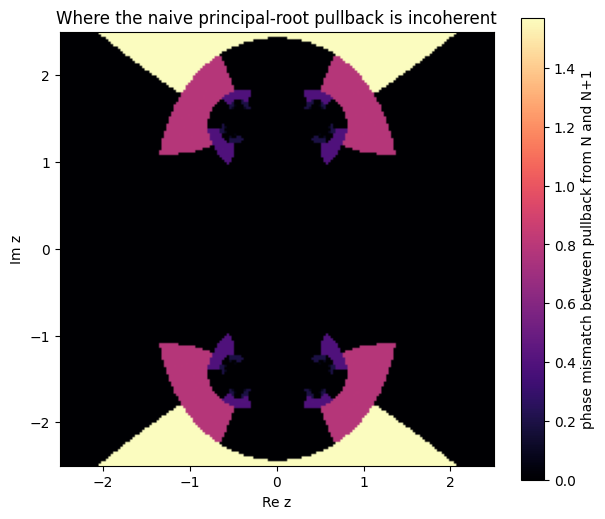

In [5]:
def phase_error_between_N_and_N1(z, N, terms=40):
    a = pullback_candidate(z, N, terms=terms)
    b = pullback_candidate(z, N + 1, terms=terms)
    if abs(a) == 0 or abs(b) == 0:
        return np.nan
    return abs(cmath.phase(a / b))

xs = np.linspace(-2.5, 2.5, 180)
ys = np.linspace(-2.5, 2.5, 180)
Z = np.empty((len(ys), len(xs)))

for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        z = x + 1j*y
        N = escape_time(z, R=4.0, max_iter=8)
        if N is None or N >= 8:
            Z[j, i] = np.nan
        else:
            Z[j, i] = phase_error_between_N_and_N1(z, N, terms=30)

plt.figure(figsize=(7, 6))
im = plt.imshow(Z, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower', cmap='magma')
plt.colorbar(im, label='phase mismatch between pullback from N and N+1')
plt.title('Where the naive principal-root pullback is incoherent')
plt.xlabel('Re z')
plt.ylabel('Im z')
plt.show()

## Formal meaning of “selected coherently”

Let $\Phi_\infty$ be the already-constructed near-infinity coordinate on an outside region $V$. For a basin point $z$, choose any escape iterate $N$ such that

$$
f^N(z)\in V.
$$

A pullback value is any solution of

$$
W_N(z)^{2^N}=\Phi_\infty(f^N(z)).
$$

Saying that the roots are **selected coherently** means more than choosing one root from this finite set. Formally, the desired basin coordinate $\Phi$ must satisfy the following conditions.

### 1. Escape-iterate independence

If $N$ and $M$ are two escape times for the same point $z$, then the pullback construction gives the same value:

$$
W_N(z)=W_M(z).
$$

Equivalently, once $\Phi(z)$ is chosen, it must satisfy

$$
\Phi(z)^{2^N}=\Phi_\infty(f^N(z))
$$

for every sufficiently large escape time $N$, not just for the first chosen one.

This is the first missing theorem behind `PrincipalPullbackCoherentDataFor`.

### 2. Compatibility between consecutive escape times

For every escape time $N$, the value chosen at time $N+1$ must be the same as the value chosen at time $N$:

$$
W_{N+1}(z)=W_N(z).
$$

Using the Böttcher equation near infinity,

$$
\Phi_\infty(f^{N+1}(z))=\Phi_\infty(f^N(z))^2,
$$

this says that the chosen $2^{N+1}$-root must be the descendant of the chosen $2^N$-root, not an unrelated root selected by the principal branch.

### 3. Local holomorphic branch choice

For every basin point $z_0$, there must be a neighborhood $U$ of $z_0$ and a holomorphic function

$$
\Phi_U:U\to\mathbb C
$$

such that for all $z\in U$ and all sufficiently large escape times $N$,

$$
\Phi_U(z)^{2^N}=\Phi_\infty(f^N(z)).
$$

This prevents the branch from jumping when $z$ moves slightly. Pointwise root choices are not enough; the chosen root must vary holomorphically.

### 4. Compatibility on overlaps

If two neighborhoods $U$ and $U'$ overlap, their local branches must agree on $U\cap U'$:

$$
\Phi_U=\Phi_{U'} \quad \text{on } U\cap U'.
$$

This gives a single global holomorphic basin coordinate, rather than unrelated local choices.

### Lean target

The current Lean seam packages the consequences of these coherence facts as

```lean
+Quadratic.PrincipalPullbackCoherentDataFor (2 : ℂ)
```

The notebook pictures show why the first two conditions are nontrivial: the principal-root rule can choose different descendants at levels $N$ and $N+1$. The formal proof must replace that naive rule by a coherent holomorphic branch selection.

## Numerical experiment: dependence on the chosen escape iterate

Escape-iterate independence says that if both $N$ and $M$ are valid escape times for the same point $z$, then pulling back from $N$ or from $M$ should give the same value:

$$
W_N(z)=W_M(z).
$$

The next plot tests this for the naive principal-root rule. For each point $z$, let $N$ be its first escape time to the outside region and compare the principal pullback from $N$ with the principal pullback from $M=N+2$.

The color is the phase mismatch

$$
\left|\arg\left(W_N(z)/W_M(z)\right)\right|.
$$

Dark means the two escape times happen to agree. Bright means the value depends on the chosen escape iterate. Those bright regions are exactly why the proof cannot just say “take the principal root.” It must construct a coherent branch selection for all valid escape times.

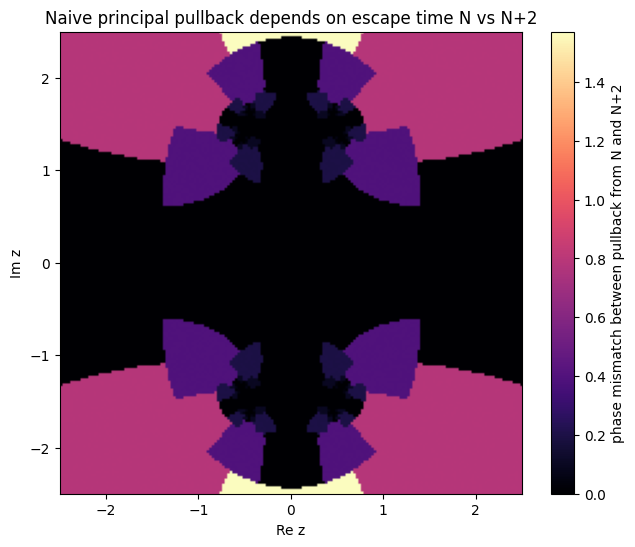

Sample points where the naive principal pullback depends strongly on escape time:
z=-0.7682-2.5j, N=1, M=3, W_N=0.868757+2.13187j, W_M=2.13187-0.868757j, phase mismatch=1.571
z=-0.7402-2.5j, N=1, M=3, W_N=0.836974+2.13023j, W_M=2.13023-0.836974j, phase mismatch=1.571
z=-0.7123-2.5j, N=1, M=3, W_N=0.805158+2.1287j, W_M=2.1287-0.805158j, phase mismatch=1.571
z=-0.6844-2.5j, N=1, M=3, W_N=0.773314+2.12728j, W_M=2.12728-0.773314j, phase mismatch=1.571
z=-0.6564-2.5j, N=1, M=3, W_N=0.74145+2.12597j, W_M=2.12597-0.74145j, phase mismatch=1.571


In [6]:
offset = 2
xs = np.linspace(-2.5, 2.5, 180)
ys = np.linspace(-2.5, 2.5, 180)
Z_nm = np.empty((len(ys), len(xs)))

examples = []
for j, y in enumerate(ys):
    for i, x in enumerate(xs):
        z = x + 1j*y
        N = escape_time(z, R=4.0, max_iter=8)
        if N is None or N + offset > 10:
            Z_nm[j, i] = np.nan
            continue
        a = pullback_candidate(z, N, terms=30)
        b = pullback_candidate(z, N + offset, terms=30)
        if abs(a) == 0 or abs(b) == 0:
            Z_nm[j, i] = np.nan
            continue
        mismatch = abs(cmath.phase(a / b))
        Z_nm[j, i] = mismatch
        if mismatch > 1.0 and len(examples) < 5:
            examples.append((z, N, N + offset, a, b, mismatch))

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(Z_nm, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin='lower', cmap='magma')
fig.colorbar(im, ax=ax, label=f'phase mismatch between pullback from N and N+{offset}')
ax.set_title(f'Naive principal pullback depends on escape time N vs N+{offset}')
ax.set_xlabel('Re z')
ax.set_ylabel('Im z')
plt.show()

print('Sample points where the naive principal pullback depends strongly on escape time:')
for z, N, M, a, b, mismatch in examples:
    print(f'z={z:.4g}, N={N}, M={M}, W_N={a:.6g}, W_M={b:.6g}, phase mismatch={mismatch:.4g}')

## Group-theoretic viewpoint: root choices as torsors

The group-theoretic approach is not a new numerical rule like “principal root” or “nearest root.” It says what the correct choice should mean formally.

Fix $z$ and an escape time $N$. Let

$$
A_N=\Phi_\infty(f^N(z)).
$$

The level-$N$ pullback roots are

$$
T_N(z)=\{w:w^{2^N}=A_N\}.
$$

This set is a torsor under the root-of-unity group

$$
\mu_{2^N}=\{\zeta:\zeta^{2^N}=1\}.
$$

If $w_N\in T_N(z)$ is one choice, every other choice is $\zeta w_N$ for a unique $\zeta\in\mu_{2^N}$.

The transition from level $N+1$ to level $N$ is controlled by the squaring map on the group:

$$
\mu_{2^{N+1}}\to\mu_{2^N},\qquad \zeta\mapsto\zeta^2.
$$

The **choice strategy** suggested by this viewpoint is:

> choose the unique root in each torsor $T_N(z)$ compatible with the normalized near-infinity basepoint under all transition maps.

Equivalently, once the branch is fixed near infinity, every lower-level root is determined by compatibility, not by a fresh principal-root decision. The proof task is to show this compatible basepoint exists, is independent of escape time, and varies holomorphically in $z$.

The visualization below shows this for a fixed point and levels $N$, $N+1$, and $N+2$. The green path is the compatible basepoint through the torsor tower. The orange markers show what happens if one reselects the principal root independently at each level.

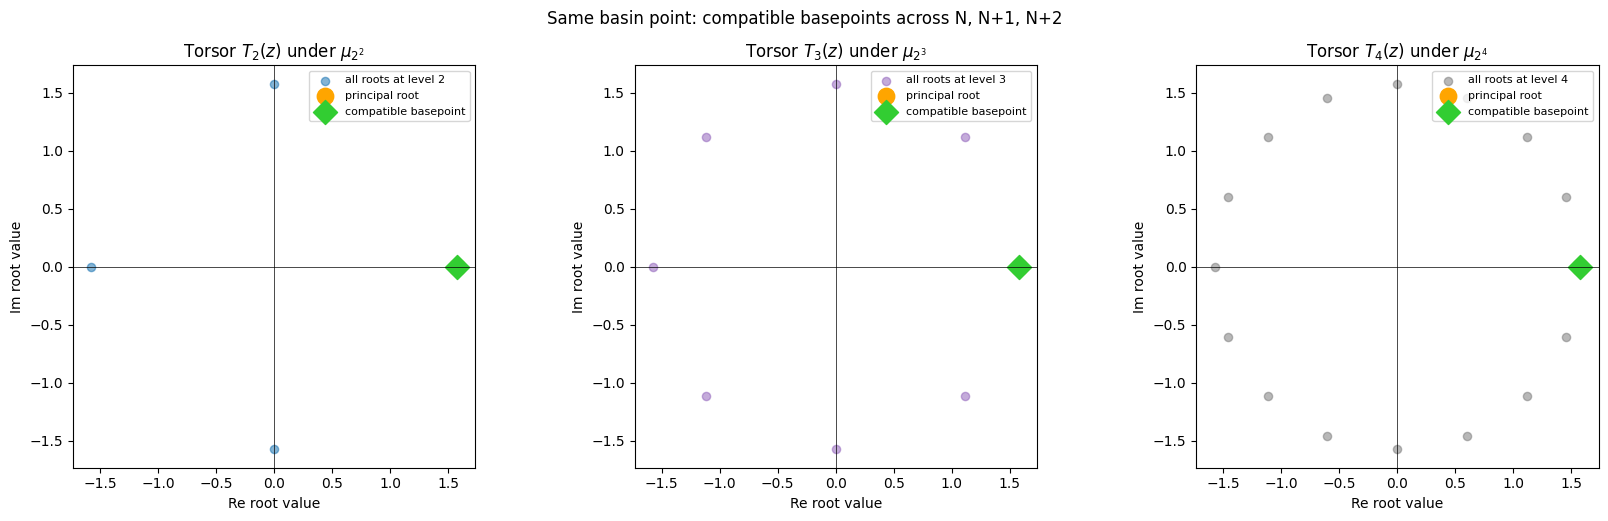

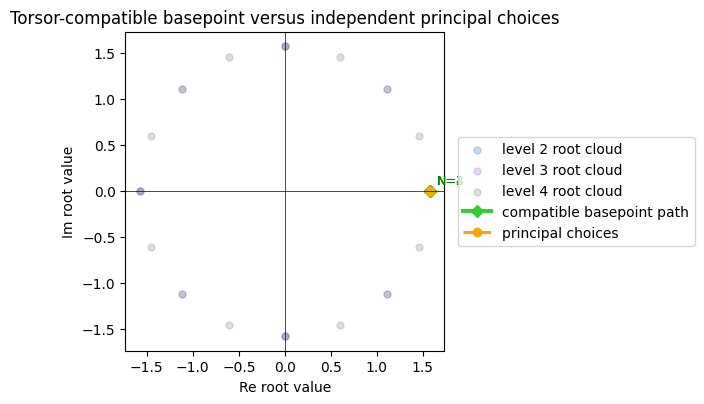

Fixed point z0 = 0j
level 2: principal=1.5758342+0j, compatible=1.5758342+0j, distance=0
level 3: principal=1.5758342+0j, compatible=1.5758342+0j, distance=0
level 4: principal=1.5758342+0j, compatible=1.5758342+0j, distance=0

Interpretation:
The green path is the candidate inverse-system basepoint through the torsors.
The proof must show this path is independent of the initial escape time and holomorphic in z.


In [7]:
def roots_of_unity(k):
    return np.array([cmath.exp(2j * math.pi * j / (2**k)) for j in range(2**k)])

def closest_root_to(target, roots):
    return roots[np.argmin(np.abs(roots - target))]

z0 = 0.0 + 0.0j
N = escape_time(z0, R=4.0, max_iter=10)
levels = [N, N + 1, N + 2]

root_clouds = []
principal = []
for L in levels:
    A = phi_inf_approx(iterate(z0, L), terms=70)
    roots = all_roots(A, 2**L)
    root_clouds.append(roots)
    principal.append(principal_root(A, 2**L))

# Torsor-compatible selection: start from the principal choice at level N, then
# at later levels choose the root closest to the already selected basepoint.
# This models the inverse-system basepoint, not a proof of it.
compatible = [principal[0]]
for j in range(1, len(levels)):
    compatible.append(closest_root_to(compatible[-1], root_clouds[j]))

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
colors = ['tab:blue', 'tab:purple', 'tab:gray']
for ax, L, roots, color, pval, cval in zip(axes, levels, root_clouds, colors, principal, compatible):
    ax.scatter(roots.real, roots.imag, s=35, color=color, alpha=0.55, label=f'all roots at level {L}')
    ax.scatter([pval.real], [pval.imag], color='orange', marker='o', s=140, label='principal root')
    ax.scatter([cval.real], [cval.imag], color='limegreen', marker='D', s=150, label='compatible basepoint')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f'Torsor $T_{{{L}}}(z)$ under $\\mu_{{2^{L}}}$')
    ax.set_xlabel('Re root value')
    ax.set_ylabel('Im root value')
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Same basin point: compatible basepoints across N, N+1, N+2')
fig.tight_layout()
plt.show()

# Draw the three compatible choices in one plot, with transitions.
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for L, roots, color in zip(levels, root_clouds, colors):
    ax.scatter(roots.real, roots.imag, s=25, alpha=0.25, color=color, label=f'level {L} root cloud')
ax.plot([v.real for v in compatible], [v.imag for v in compatible], 'D-', color='limegreen', linewidth=2.8, label='compatible basepoint path')
ax.plot([v.real for v in principal], [v.imag for v in principal], 'o--', color='orange', linewidth=2.2, label='principal choices')
for L, v in zip(levels, compatible):
    ax.annotate(f'N={L}', (v.real, v.imag), textcoords='offset points', xytext=(5, 5), fontsize=9, color='green')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Torsor-compatible basepoint versus independent principal choices')
ax.set_xlabel('Re root value')
ax.set_ylabel('Im root value')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()

print('Fixed point z0 =', z0)
for L, pval, cval in zip(levels, principal, compatible):
    print(f'level {L}: principal={pval:.8g}, compatible={cval:.8g}, distance={abs(pval-cval):.4g}')
print('\nInterpretation:')
print('The green path is the candidate inverse-system basepoint through the torsors.')
print('The proof must show this path is independent of the initial escape time and holomorphic in z.')

## What the Lean proof still needs

The formal target `PrincipalPullbackCoherentDataFor (2 : ℂ)` needs a theorem saying that the chosen pullback branches:

1. do not depend on which escape iterate is used;
2. vary holomorphically on neighborhoods in the basin;
3. preserve semiconjugacy $\Phi(f(z))=\Phi(z)^2$;
4. give the correct modulus $|\Phi(z)|=e^{G(z)}$.

The plots above show why this is a branch-coherence theorem, not just an algebraic identity. Algebraically, roots exist. Geometrically and analytically, the roots must be selected coherently along orbits and across neighborhoods.